# Predicción del Abandono de Empleados
## Machine Learning - Ejercicio 5

## Integrantes

| Nombre |
|---|
| Diego Ramirez |
| Liliana Arias |
| Andres Botero |
| Mateo Bolivar |

---

---
## Punto 1 - Descripción del Problema

El objetivo de este ejercicio es construir un modelo predictivo capaz de identificar empleados con alta probabilidad de **abandonar la empresa**, a partir de variables como:

- Nivel de satisfacción laboral
- Última evaluación de desempeño
- Número de proyectos asignados
- Promedio de horas mensuales trabajadas
- Tiempo en la empresa (antigüedad)
- Accidentes laborales
- Promoción en los últimos 5 años
- Departamento y nivel salarial

El problema corresponde a una **clasificación binaria supervisada**:
- `1` → El empleado abandona la empresa
- `0` → El empleado permanece en la empresa

**Dataset:** HR Analytics - Employee Attrition  
**Archivo:** `HR_comma_sep.csv`  
**Observaciones:** 14,999 empleados | 10 variables

## Punto 2 - Importación de librerías

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=PendingDeprecationWarning, module='seaborn')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

from sklearn.decomposition import PCA

## Punto 3 - Carga de datos

In [2]:
df = pd.read_csv('HR_comma_sep.csv')

df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Punto 4 - Exploración de datos (EDA)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [5]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [ ]:
# Distribución de la variable objetivo
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='left', data=df, hue='left', legend=False, palette='Set2')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Permanece (0)', 'Abandona (1)'])
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )
plt.title('Distribución de Abandono (left)')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

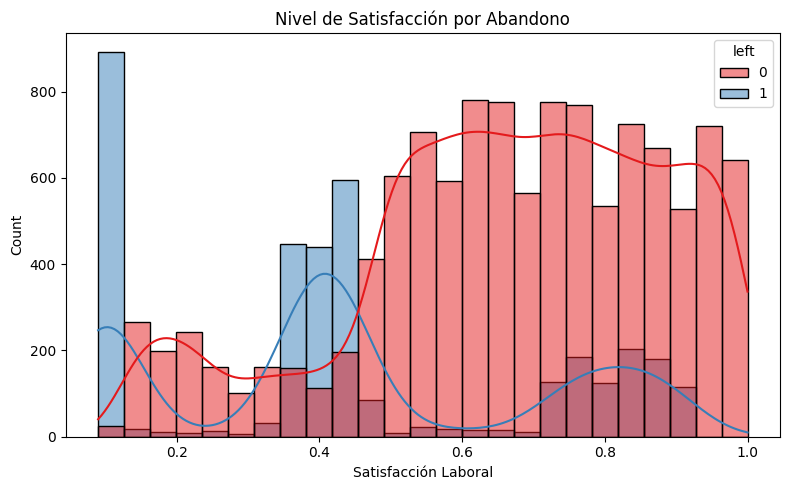

In [7]:
# Satisfacción laboral vs abandono
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='satisfaction_level', hue='left', kde=True, bins=25, palette='Set1')
plt.title('Nivel de Satisfacción por Abandono')
plt.xlabel('Satisfacción Laboral')
plt.tight_layout()
plt.show()

In [ ]:
# Última evaluación y horas mensuales vs abandono
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='left', y='last_evaluation', data=df, hue='left', legend=False, palette='pastel', ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Permanece', 'Abandona'])
axes[0].set_title('Última Evaluación vs Abandono')

sns.boxplot(x='left', y='average_montly_hours', data=df, hue='left', legend=False, palette='pastel', ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Permanece', 'Abandona'])
axes[1].set_title('Horas Mensuales vs Abandono')

plt.tight_layout()
plt.show()

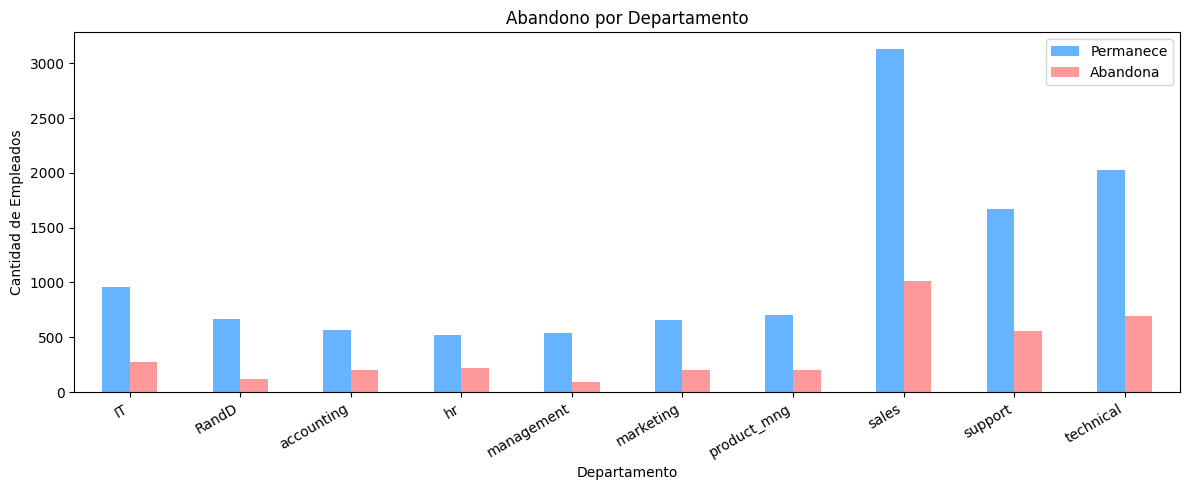

In [9]:
# Abandono por departamento
dept_attrition = df.groupby(['Department', 'left']).size().unstack(fill_value=0)
dept_attrition.plot(kind='bar', color=['#66b3ff', '#ff9999'], figsize=(12, 5))
plt.title('Abandono por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Cantidad de Empleados')
plt.xticks(rotation=30, ha='right')
plt.legend(['Permanece', 'Abandona'])
plt.tight_layout()
plt.show()

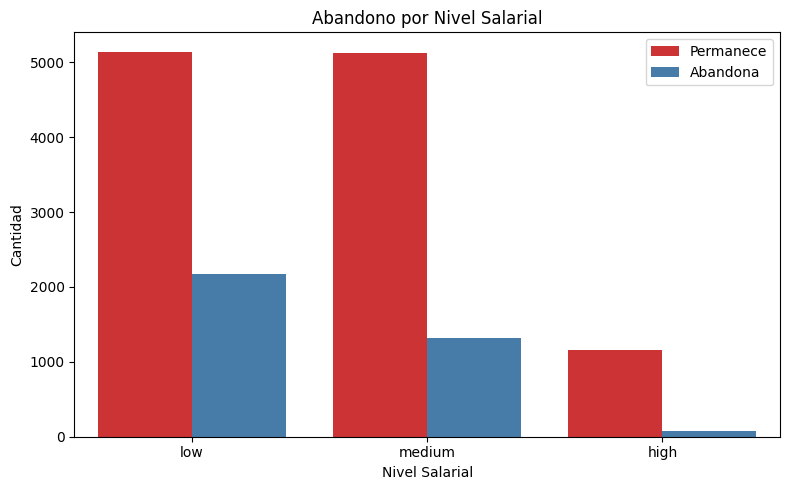

In [10]:
# Abandono por nivel salarial
plt.figure(figsize=(8, 5))
salary_order = ['low', 'medium', 'high']
sns.countplot(x='salary', hue='left', data=df, order=salary_order, palette='Set1')
plt.title('Abandono por Nivel Salarial')
plt.xlabel('Nivel Salarial')
plt.ylabel('Cantidad')
plt.legend(['Permanece', 'Abandona'])
plt.tight_layout()
plt.show()

In [ ]:
# Tiempo en la empresa y proyectos vs abandono
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='left', y='time_spend_company', data=df, hue='left', legend=False, palette='Set2', ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Permanece', 'Abandona'])
axes[0].set_title('Antigüedad en la Empresa vs Abandono')

sns.countplot(x='number_project', hue='left', data=df, palette='Set1', ax=axes[1])
axes[1].set_title('Número de Proyectos vs Abandono')
axes[1].legend(['Permanece', 'Abandona'])

plt.tight_layout()
plt.show()

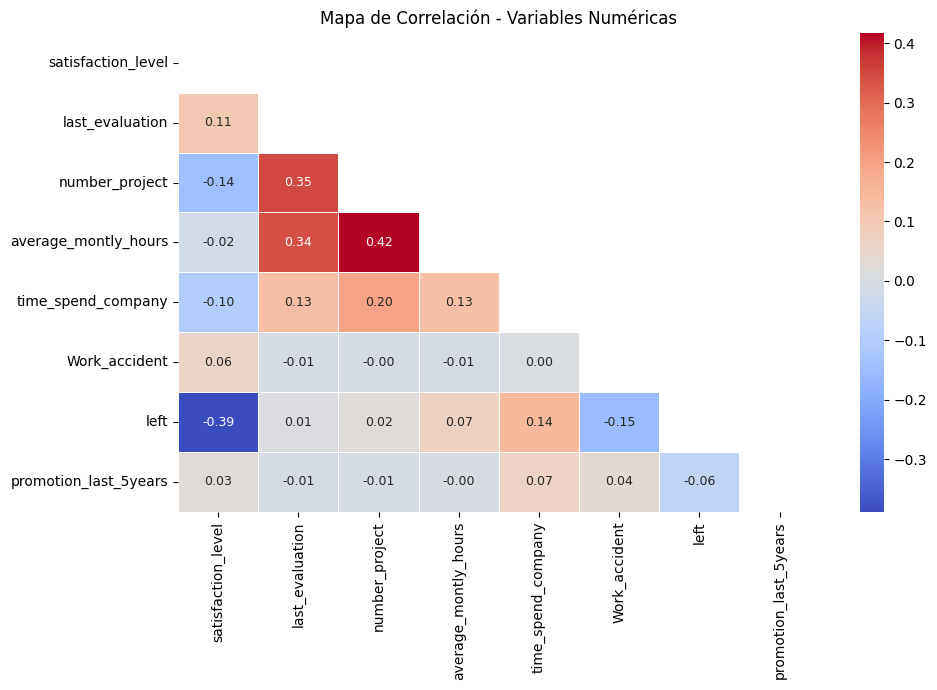

In [12]:
# Mapa de correlación variables numéricas
plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, linewidths=0.5, annot_kws={'size': 9}
)
plt.title('Mapa de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

## Punto 5 - Preprocesamiento

In [13]:
# La variable objetivo 'left' ya está codificada como 0/1
X = df.drop('left', axis=1)
y = df['left']

print(f'Distribución de clases:\n{y.value_counts()}')
print(f'\nProporción de abandono: {y.mean():.2%}')

Distribución de clases:
left
0    11428
1     3571
Name: count, dtype: int64

Proporción de abandono: 23.81%


In [ ]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f'Features numéricas ({len(numeric_features)}): {numeric_features}')
print(f'\nFeatures categóricas ({len(categorical_features)}): {categorical_features}')

In [15]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')
print(f'Clases en train: {dict(y_train.value_counts())}')

Entrenamiento: 11999 muestras
Prueba:        3000 muestras
Clases en train: {0: np.int64(9142), 1: np.int64(2857)}


## Punto 6 - Modelo 1: Regresión Logística

La regresión logística es un modelo lineal interpretable para clasificación binaria. Dado el desbalance de clases (~24% abandono), se usa `class_weight='balanced'` para dar mayor peso a la clase minoritaria.

In [17]:
modelo_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)
prob_lr = modelo_lr.predict_proba(X_test)[:, 1]

In [18]:
print('=== Regresión Logística ===')
print(f'Accuracy:  {accuracy_score(y_test, pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, pred_lr):.4f}')
print(f'Recall:    {recall_score(y_test, pred_lr):.4f}')
print(f'F1-score:  {f1_score(y_test, pred_lr):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, prob_lr):.4f}')
print('\nReporte de Clasificación:')
print(classification_report(y_test, pred_lr, target_names=['No abandona', 'Abandona']))

=== Regresión Logística ===
Accuracy:  0.7727
Precision: 0.5143
Recall:    0.8053
F1-score:  0.6277
ROC-AUC:   0.8370

Reporte de Clasificación:
              precision    recall  f1-score   support

 No abandona       0.93      0.76      0.84      2286
    Abandona       0.51      0.81      0.63       714

    accuracy                           0.77      3000
   macro avg       0.72      0.78      0.73      3000
weighted avg       0.83      0.77      0.79      3000



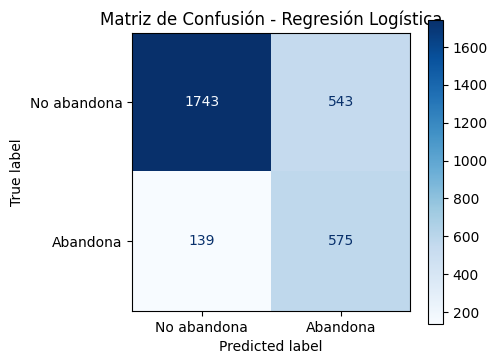

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_lr,
    display_labels=['No abandona', 'Abandona'],
    cmap='Blues', ax=ax
)
plt.title('Matriz de Confusión - Regresión Logística')
plt.tight_layout()
plt.show()

## Punto 7 - Modelo 2: Árbol de Decisión

El árbol de decisión captura relaciones no lineales y genera reglas interpretables. Se limita la profundidad (`max_depth=5`) para evitar sobreajuste.

In [20]:
modelo_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
])

modelo_dt.fit(X_train, y_train)

pred_dt = modelo_dt.predict(X_test)
prob_dt = modelo_dt.predict_proba(X_test)[:, 1]

In [21]:
print('=== Árbol de Decisión ===')
print(f'Accuracy:  {accuracy_score(y_test, pred_dt):.4f}')
print(f'Precision: {precision_score(y_test, pred_dt):.4f}')
print(f'Recall:    {recall_score(y_test, pred_dt):.4f}')
print(f'F1-score:  {f1_score(y_test, pred_dt):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, prob_dt):.4f}')
print('\nReporte de Clasificación:')
print(classification_report(y_test, pred_dt, target_names=['No abandona', 'Abandona']))

=== Árbol de Decisión ===
Accuracy:  0.9397
Precision: 0.8238
Recall:    0.9496
F1-score:  0.8822
ROC-AUC:   0.9595

Reporte de Clasificación:
              precision    recall  f1-score   support

 No abandona       0.98      0.94      0.96      2286
    Abandona       0.82      0.95      0.88       714

    accuracy                           0.94      3000
   macro avg       0.90      0.94      0.92      3000
weighted avg       0.95      0.94      0.94      3000



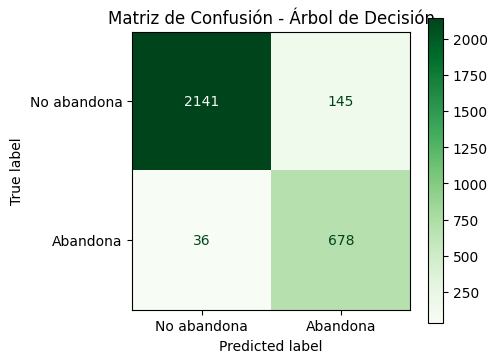

In [22]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_dt,
    display_labels=['No abandona', 'Abandona'],
    cmap='Greens', ax=ax
)
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.tight_layout()
plt.show()

## Punto 8 - Modelo 3: Random Forest

Random Forest es un ensamble de árboles que reduce la varianza mediante bagging. Suele obtener mejor generalización que un árbol individual y permite extraer la importancia de variables.

In [23]:
modelo_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)
prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

In [24]:
print('=== Random Forest ===')
print(f'Accuracy:  {accuracy_score(y_test, pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, pred_rf):.4f}')
print(f'Recall:    {recall_score(y_test, pred_rf):.4f}')
print(f'F1-score:  {f1_score(y_test, pred_rf):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, prob_rf):.4f}')
print('\nReporte de Clasificación:')
print(classification_report(y_test, pred_rf, target_names=['No abandona', 'Abandona']))

=== Random Forest ===
Accuracy:  0.9897
Precision: 0.9942
Recall:    0.9622
F1-score:  0.9779
ROC-AUC:   0.9916

Reporte de Clasificación:
              precision    recall  f1-score   support

 No abandona       0.99      1.00      0.99      2286
    Abandona       0.99      0.96      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



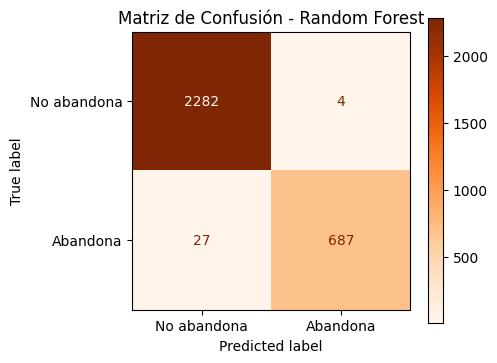

In [25]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_rf,
    display_labels=['No abandona', 'Abandona'],
    cmap='Oranges', ax=ax
)
plt.title('Matriz de Confusión - Random Forest')
plt.tight_layout()
plt.show()

## Punto 9 - Comparación de Modelos

In [26]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf)
    ],
    'Precision': [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_dt),
        precision_score(y_test, pred_rf)
    ],
    'Recall': [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_dt),
        recall_score(y_test, pred_rf)
    ],
    'F1-score': [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_dt),
        f1_score(y_test, pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, prob_lr),
        roc_auc_score(y_test, prob_dt),
        roc_auc_score(y_test, prob_rf)
    ]
})

print(resultados.round(4).to_string(index=False))

             Modelo  Accuracy  Precision  Recall  F1-score  ROC-AUC
Regresión Logística    0.7727     0.5143  0.8053    0.6277   0.8370
  Árbol de Decisión    0.9397     0.8238  0.9496    0.8822   0.9595
      Random Forest    0.9897     0.9942  0.9622    0.9779   0.9916


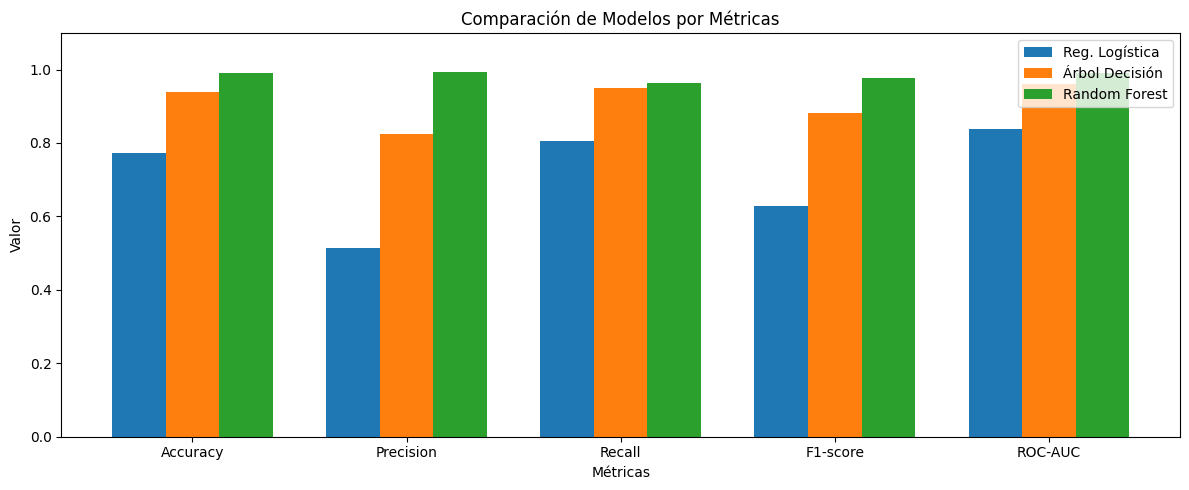

In [27]:
# Gráfico comparativo de métricas
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
x = np.arange(len(metricas))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

for i, (nombre, preds, probs) in enumerate([
    ('Reg. Logística', pred_lr, prob_lr),
    ('Árbol Decisión', pred_dt, prob_dt),
    ('Random Forest',  pred_rf, prob_rf)
]):
    valores = [
        accuracy_score(y_test, preds),
        precision_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds),
        roc_auc_score(y_test, probs)
    ]
    ax.bar(x + i * width, valores, width, label=nombre)

ax.set_xlabel('Métricas')
ax.set_ylabel('Valor')
ax.set_title('Comparación de Modelos por Métricas')
ax.set_xticks(x + width)
ax.set_xticklabels(metricas)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## Punto 10 - Curvas ROC-AUC

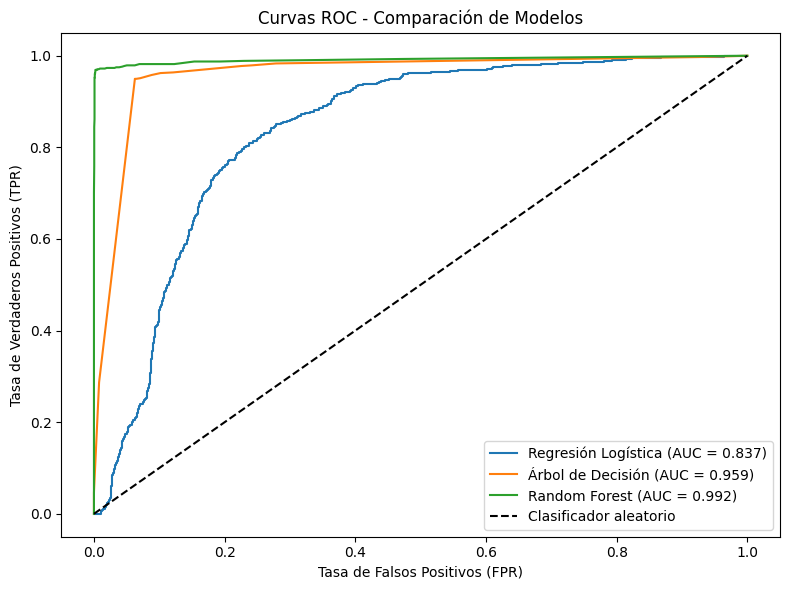

In [28]:
plt.figure(figsize=(8, 6))

for nombre, prob in [
    ('Regresión Logística', prob_lr),
    ('Árbol de Decisión',   prob_dt),
    ('Random Forest',       prob_rf)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC - Comparación de Modelos')
plt.legend()
plt.tight_layout()
plt.show()

## Punto 11 - Importancia de Variables

In [ ]:
# Extraer nombres de características del preprocessor ajustado
preprocessor_fit = modelo_rf.named_steps['preprocessor']
cat_encoder = preprocessor_fit.named_transformers_['cat'].named_steps['encoder']
cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_names

# Importancias del Random Forest
rf_clf = modelo_rf.named_steps['classifier']
importances = rf_clf.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, hue='Feature', legend=False, palette='viridis')
plt.title('Top 15 Variables más Importantes - Random Forest')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

print('\nTop 10 variables más importantes:')
print(feat_imp_df.head(10).to_string(index=False))

## Punto 12 - Visualización PCA

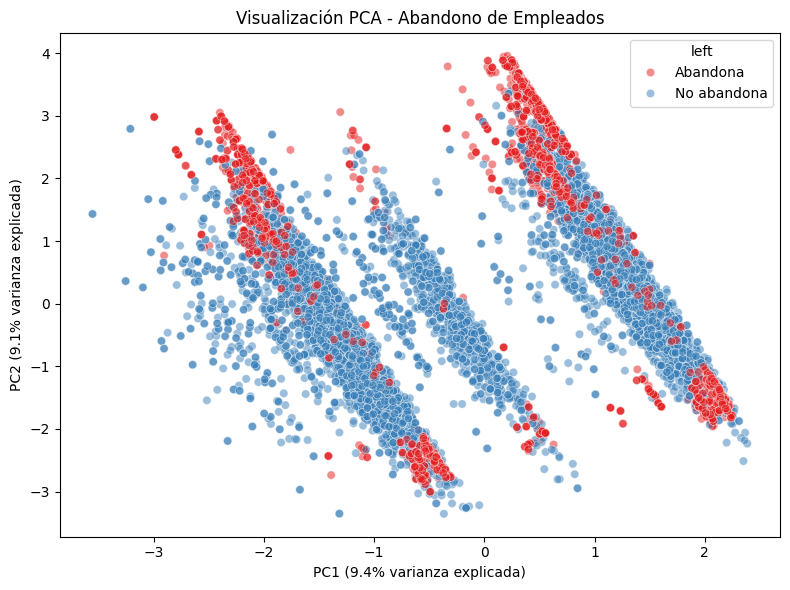

In [30]:
X_encoded = pd.get_dummies(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y.map({1: 'Abandona', 0: 'No abandona'}),
    palette='Set1',
    alpha=0.5
)
plt.title('Visualización PCA - Abandono de Empleados')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza explicada)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza explicada)')
plt.tight_layout()
plt.show()

## Punto 13 - Conclusiones y Acciones Preventivas

### Justificación de los algoritmos

| Modelo | Justificación |
|---|---|
| **Regresión Logística** | Modelo base interpretable para clasificación binaria. Robusto, rápido y útil como línea de referencia. |
| **Árbol de Decisión** | Captura relaciones no lineales y genera reglas claras. Útil para comunicar resultados al área de RRHH. |
| **Random Forest** | Ensamble que reduce varianza mediante bagging. Mejor generalización y permite analizar importancia de variables. |

### Hallazgos del Modelo

| Modelo | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---|---|---|---|---|
| Regresión Logística | 0.7727 | 0.5143 | 0.8053 | 0.6277 | 0.8370 |
| Árbol de Decisión   | 0.9397 | 0.8238 | 0.9496 | 0.8822 | 0.9595 |
| **Random Forest**   | **0.9897** | **0.9942** | **0.9622** | **0.9779** | **0.9916** |

- **Random Forest** obtuvo el mejor desempeño en todas las métricas (F1=0.9779, ROC-AUC=0.9916).
- El dataset presenta **desbalance de clases** (~24% abandono), manejado con `class_weight='balanced'` en todos los modelos.
- Las 5 variables de mayor importancia según Random Forest fueron: **satisfaction_level** (0.272), **time_spend_company** (0.228), **average_montly_hours** (0.153), **number_project** (0.151) y **last_evaluation** (0.138). En conjunto explican más del 94% de la capacidad predictiva del modelo.
- Las variables `promotion_last_5years` (importancia: 0.002) y `salary` (importancia combinada: ~0.018) resultaron tener **bajo peso predictivo** en el modelo.

### Variables Clave de Riesgo

1. **satisfaction_level** (importancia: 0.272): La insatisfacción laboral es el predictor más fuerte de abandono.
2. **time_spend_company** (importancia: 0.228): Los empleados con 4-6 años de antigüedad presentan mayor riesgo de abandono.
3. **average_montly_hours** (importancia: 0.153): Tanto la sobrecarga (>250 h/mes) como la subcarga (<150 h/mes) se asocian con abandono.
4. **number_project** (importancia: 0.151): Tener demasiados proyectos simultáneos aumenta el riesgo de burnout y abandono.
5. **last_evaluation** (importancia: 0.138): Empleados con evaluaciones muy bajas o muy altas tienden a abandonar más.

### Acciones Preventivas Propuestas

- **Encuestas de satisfacción periódicas**: Identificar empleados con bajo índice de satisfacción antes de que tomen la decisión de irse. Es la variable más predictiva del modelo.
- **Control de carga de trabajo**: Monitorear el número de proyectos y las horas mensuales por empleado; evitar tanto el burnout (sobrecarga) como la infrautilización.
- **Gestión de la experiencia en el rango 4-6 años**: Es el período de mayor riesgo según `time_spend_company`; implementar programas de fidelización y reconocimiento específicos.
- **Retención de alto desempeño**: Los empleados con evaluaciones altas pero insatisfechos son los más valiosos y vulnerables al abandono.
- **Revisión salarial competitiva**: Aunque `salary` tiene bajo peso en el modelo predictivo, ajustar salarios bajos sigue siendo una práctica de retención recomendable a largo plazo.

### Implicaciones Éticas

- El modelo **no debe utilizarse para discriminar ni tomar decisiones de despido** preventivamente.
- Los datos personales de los empleados deben protegerse bajo normativas de privacidad vigentes.
- Las predicciones deben **complementarse con evaluación humana y contextual** por parte de RRHH.
- Debe revisarse el modelo para evitar sesgos por departamento, género u otras características protegidas.
- El objetivo del modelo es **apoyar la gestión de talento y el bienestar organizacional**, no sancionar empleados.